In [ ]:
#import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/adult.csv')

print("Adult Census Income dataset loaded successfully.")

Adult Census Income dataset loaded successfully.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.shape

(32561, 15)

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 24


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
(df == '?').sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df.replace('?', np.nan, inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
categorical_cols = [
    'workclass',
    'occupation',
    'native.country'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [ ]:
df.drop(['fnlwgt'], axis=1, inplace=True)

In [ ]:
df.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])
df['income'].value_counts()

,count
income,
0,24698
1,7839


In [ ]:
categorical_cols = [
    'workclass',
    'education',
    'marital.status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native.country'
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [ ]:
df['capital_net'] = df['capital.gain'] - df['capital.loss']

print(df[['capital.gain', 'capital.loss', 'capital_net']].head())

   capital.gain  capital.loss  capital_net
0             0          4356        -4356
1             0          4356        -4356
2             0          4356        -4356
3             0          3900        -3900
4             0          3900        -3900


In [ ]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

print("IQR:", IQR)

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

IQR: 20.0


In [ ]:
df = df[
    (df['age'] >= lower_limit) &
    (df['age'] <= upper_limit)
]

df.shape

(32395, 98)

In [ ]:
Q1 = df['capital.gain'].quantile(0.25)
Q3 = df['capital.gain'].quantile(0.75)

IQR = Q3 - Q1

print("IQR:", IQR)

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

IQR: 0.0


In [ ]:
df = df[
    (df['capital.gain'] >= lower_limit) &
    (df['capital.gain'] <= upper_limit)
]

df.shape

(29703, 98)

In [ ]:
X = df.drop('income', axis=1)
y = df['income']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

cols_to_scale = [
    'age',
    'education.num',
    'capital.gain',
    'capital.loss',
    'hours.per.week',
    'capital_net'
]

X_train[cols_to_scale] = scaler.fit_transform(
    X_train[cols_to_scale]
)

X_test[cols_to_scale] = scaler.transform(
    X_test[cols_to_scale]
)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8508963891928288
Testing Accuracy: 0.8495202827806767


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8495202827806767


In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[4434  313]
 [ 581  613]]


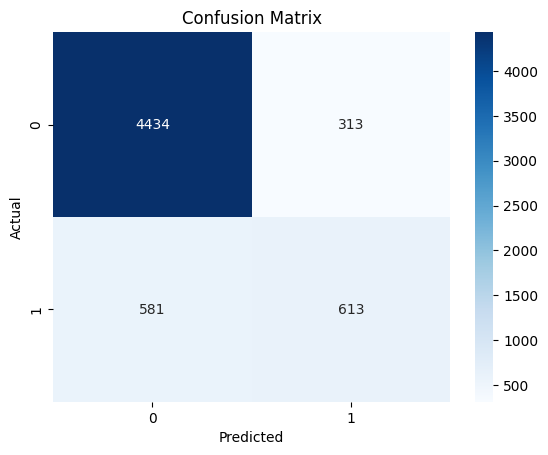

In [ ]:
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4747
           1       0.66      0.51      0.58      1194

    accuracy                           0.85      5941
   macro avg       0.77      0.72      0.74      5941
weighted avg       0.84      0.85      0.84      5941



In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

auc_score = roc_auc_score(y_test, y_pred)

print("AUC Score:", auc_score)

AUC Score: 0.7237319770681226


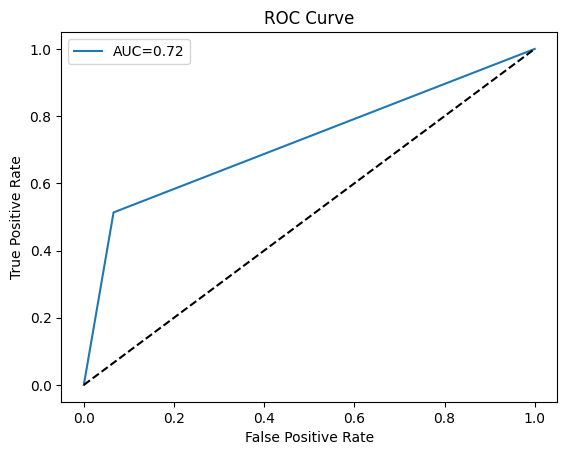

In [ ]:
plt.plot(
    fpr,
    tpr,
    label='AUC={:.2f}'.format(auc_score)
)

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()